In [1]:
import os

# Fix TF/protobuf runtime crash: force pure-Python protobuf implementation before importing TF.
# This addresses: AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydicom  # unused but kept to preserve original environment assumptions
from sklearn.linear_model import LinearRegression  # unused but kept
from sklearn.preprocessing import PolynomialFeatures  # unused but kept
from sklearn.ensemble import RandomForestRegressor  # unused but kept
from skimage import morphology  # unused but kept
from skimage import measure  # unused but kept
from skimage.transform import resize  # unused but kept
from sklearn.cluster import KMeans  # unused but kept
import matplotlib.patches as patches  # unused but kept

np.random.seed(42)

# Make DATA_DIR robust to this environment while keeping the original relative path as first choice.
DATA_DIR = "../input/osic-pulmonary-fibrosis-progression"
if not os.path.exists(DATA_DIR):
    alt = "/kaggle/input/osic-pulmonary-fibrosis-progression"
    if os.path.exists(alt):
        DATA_DIR = alt

print("Using DATA_DIR:", DATA_DIR)



Using DATA_DIR: ../input/osic-pulmonary-fibrosis-progression


In [2]:
train_csv = pd.read_csv(f"{DATA_DIR}/train.csv")



In [3]:
train_csv



,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00133637202223847701934,-2,3195,92.856312,83,Male,Never smoked
1,ID00133637202223847701934,2,3203,93.088817,83,Male,Never smoked
2,ID00133637202223847701934,4,3097,90.008138,83,Male,Never smoked
3,ID00133637202223847701934,6,3171,92.158800,83,Male,Never smoked
4,ID00133637202223847701934,8,3115,90.531272,83,Male,Never smoked
...,...,...,...,...,...,...,...
1389,ID00421637202311550012437,29,2716,81.356338,68,Male,Ex-smoker
1390,ID00421637202311550012437,41,2833,84.861011,68,Male,Ex-smoker
1391,ID00421637202311550012437,54,2771,83.003834,68,Male,Ex-smoker
1392,ID00421637202311550012437,70,2628,78.720345,68,Male,Ex-smoker


In [4]:
base_week = train_csv.groupby("Patient")["Weeks"].min()

base_week_list = []
for i in range(len(train_csv)):
    base_week_list.append(base_week[train_csv.iloc[i, 0]])
train_csv["base_week"] = base_week_list

base_week = train_csv.groupby("Patient")["Weeks"].min()
count_from_base_week = []
for i in range(len(train_csv)):
    count_from_base_week.append(train_csv.iloc[i, 1] - base_week[train_csv.iloc[i, 0]])
train_csv["count_from_base_week"] = count_from_base_week

confidence = np.zeros(train_csv.shape[0])
train_csv["confidence"] = confidence

base_fvc_dict = {}
for pid in train_csv["Patient"].unique():
    base_fvc_dict[pid] = np.array(
        train_csv[
            (train_csv["Patient"] == pid) & (train_csv["Weeks"] == base_week[pid])
        ]["FVC"]
    )[0]
base_fvc = []
for i in range(len(train_csv)):
    base_fvc.append(base_fvc_dict[train_csv.iloc[i, 0]])
train_csv["base_fvc"] = base_fvc

base_fev1_dict = {}
for pid in train_csv["Patient"].unique():
    A = train_csv[train_csv["Patient"] == pid]["base_fvc"].unique()[0]
    B = train_csv[train_csv["Patient"] == pid]["Age"].unique()[0]
    if train_csv[train_csv["Patient"] == pid]["Sex"].unique()[0] == "Male":
        base_fev1_dict[pid] = 0.77 * A + 0.32 + 0.0069 * B
    else:
        base_fev1_dict[pid] = 0.77 * A + 0.28 + 0.0052 * B

base_fev1 = []
for i in range(len(train_csv)):
    base_fev1.append(base_fev1_dict[train_csv.iloc[i, 0]])
train_csv["base_fev1"] = base_fev1

base_week_percent_dict = {}
for pid in train_csv["Patient"].unique():
    base_week_percent_dict[pid] = np.array(
        train_csv[
            (train_csv["Patient"] == pid) & (train_csv["Weeks"] == base_week[pid])
        ]["Percent"]
    )[0]

base_week_percent = []
for i in range(len(train_csv)):
    base_week_percent.append(base_week_percent_dict[train_csv.iloc[i, 0]])
train_csv["base_week_percent"] = base_week_percent

train_csv["base fev1/base fvc"] = train_csv["base_fev1"] / train_csv["base_fvc"]
train_csv["base_height"] = (train_csv["base_fvc"] + 9030) / 77.0

base_weight_dict = {}
for pid in train_csv["Patient"].unique():
    FVC = train_csv[train_csv["Patient"] == pid]["base_fvc"].unique()[0]
    A = train_csv[train_csv["Patient"] == pid]["Age"].unique()[0]
    H = train_csv[train_csv["Patient"] == pid]["base_height"].unique()[0]
    if train_csv[train_csv["Patient"] == pid]["Sex"].unique()[0] == "Male":
        base_weight_dict[pid] = (FVC + 5458 - 49 * H + 8 * A) / 12.0
    else:
        base_weight_dict[pid] = (FVC + 3863 - 37 * H + 6 * A) / 14.0

base_weight = []
for i in range(len(train_csv)):
    base_weight.append(base_weight_dict[train_csv.iloc[i, 0]])
train_csv["base_weight"] = base_weight

train_csv["base_bmi"] = train_csv["base_weight"] / (
    (train_csv["base_height"] / 100) ** 2
)



In [5]:
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()  # sex
train_csv.iloc[:, 5] = lb.fit_transform(train_csv.iloc[:, 5])

lb2 = LabelEncoder()  # SmokingStatus (kept to preserve original core logic)
train_csv.iloc[:, 6] = lb2.fit_transform(train_csv.iloc[:, 6])



In [6]:
from sklearn.preprocessing import OneHotEncoder

oh1 = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
smoke_cat = pd.DataFrame(
    oh1.fit_transform(train_csv[["SmokingStatus"]].astype(str)),
    columns=["smoking cat 0", "smoking cat 1", "smoking cat 2"],
)
train_csv = pd.concat([train_csv, smoke_cat], axis=1)



In [7]:
train_csv



,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus,base_week,count_from_base_week,confidence,base_fvc,base_fev1,base_week_percent,base fev1/base fvc,base_height,base_weight,base_bmi,smoking cat 0,smoking cat 1,smoking cat 2
0,ID00133637202223847701934,-2,3195,92.856312,83,1,2,-2,0,0.0,3195,2461.0427,92.856312,0.770279,158.766234,128.121212,50.828203,0.0,0.0,1.0
1,ID00133637202223847701934,2,3203,93.088817,83,1,2,-2,4,0.0,3195,2461.0427,92.856312,0.770279,158.766234,128.121212,50.828203,0.0,0.0,1.0
2,ID00133637202223847701934,4,3097,90.008138,83,1,2,-2,6,0.0,3195,2461.0427,92.856312,0.770279,158.766234,128.121212,50.828203,0.0,0.0,1.0
3,ID00133637202223847701934,6,3171,92.158800,83,1,2,-2,8,0.0,3195,2461.0427,92.856312,0.770279,158.766234,128.121212,50.828203,0.0,0.0,1.0
4,ID00133637202223847701934,8,3115,90.531272,83,1,2,-2,10,0.0,3195,2461.0427,92.856312,0.770279,158.766234,128.121212,50.828203,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1389,ID00421637202311550012437,29,2716,81.356338,68,1,1,15,14,0.0,2739,2109.8192,82.045291,0.770288,152.844156,104.303030,44.647716,0.0,1.0,0.0
1390,ID00421637202311550012437,41,2833,84.861011,68,1,1,15,26,0.0,2739,2109.8192,82.045291,0.770288,152.844156,104.303030,44.647716,0.0,1.0,0.0
1391,ID00421637202311550012437,54,2771,83.003834,68,1,1,15,39,0.0,2739,2109.8192,82.045291,0.770288,152.844156,104.303030,44.647716,0.0,1.0,0.0
1392,ID00421637202311550012437,70,2628,78.720345,68,1,1,15,55,0.0,2739,2109.8192,82.045291,0.770288,152.844156,104.303030,44.647716,0.0,1.0,0.0


In [8]:
sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")
test_csv = pd.read_csv(f"{DATA_DIR}/test.csv")



In [9]:
test_week = []
patient_id = []
for i in range(len(sub)):
    test_week.append(int(sub.iloc[i, 0].split("_")[-1]))
    patient_id.append(sub.iloc[i, 0].split("_")[0])

sub["Patient_Week"] = sub["Patient_Week"]  # keep explicit
sub["Patient"] = patient_id
sub["Weeks"] = test_week

sub.drop(["FVC", "Confidence"], axis=1, inplace=True)

base_fvc = test_csv.groupby("Patient")["FVC"].min()
fvc = []
for i in range(len(sub)):
    fvc.append(base_fvc[sub.iloc[i, 1]])
sub["base_fvc"] = fvc

base_fev1_dict_test = {}
for pid in sub["Patient"].unique():
    A = sub[sub["Patient"] == pid]["base_fvc"].unique()[0]
    B = test_csv[test_csv["Patient"] == pid]["Age"].unique()[0]
    if test_csv[test_csv["Patient"] == pid]["Sex"].unique()[0] == "Male":
        base_fev1_dict_test[pid] = 0.77 * A + 0.32 + 0.0069 * B
    else:
        base_fev1_dict_test[pid] = 0.77 * A + 0.28 + 0.0052 * B

base_fev1_test = []
for i in range(len(sub)):
    base_fev1_test.append(base_fev1_dict_test[sub.iloc[i, 1]])
sub["base_fev1"] = base_fev1_test

sub["base_height"] = (sub["base_fvc"] + 9030) / 77.0

base_weight_dict_test = {}
for pid in sub["Patient"].unique():
    FVC = sub[sub["Patient"] == pid]["base_fvc"].unique()[0]
    A = test_csv[test_csv["Patient"] == pid]["Age"].unique()[0]
    H = sub[sub["Patient"] == pid]["base_height"].unique()[0]
    if test_csv[test_csv["Patient"] == pid]["Sex"].unique()[0] == "Male":
        base_weight_dict_test[pid] = (FVC + 5458 - 49 * H + 8 * A) / 12.0
    else:
        base_weight_dict_test[pid] = (FVC + 3863 - 37 * H + 6 * A) / 14.0

base_weight_test = []
for i in range(len(sub)):
    base_weight_test.append(base_weight_dict_test[sub.iloc[i, 1]])
sub["base_weight"] = base_weight_test

test_csv.iloc[:, 5] = lb.transform(test_csv.iloc[:, 5])
test_csv.iloc[:, 6] = lb2.transform(test_csv.iloc[:, 6])

percent_dict = {}
sex_dict = {}
age_dict = {}
ss_dict = {}
for pid in test_csv["Patient"].unique():
    row = test_csv[test_csv["Patient"] == pid].iloc[0]
    percent_dict[pid] = float(row["Percent"])
    sex_dict[pid] = int(row["Sex"])
    age_dict[pid] = int(row["Age"])
    ss_dict[pid] = int(row["SmokingStatus"])

percent = []
sex = []
age = []
ss = []
for i in range(len(sub)):
    percent.append(percent_dict[sub.iloc[i, 1]])
    sex.append(sex_dict[sub.iloc[i, 1]])
    age.append(age_dict[sub.iloc[i, 1]])
    ss.append(ss_dict[sub.iloc[i, 1]])

sub["base_week_percent"] = percent
sub["Age"] = age
sub["Sex"] = sex
sub["SmokingStatus"] = ss

base_week_test = test_csv.groupby("Patient")["Weeks"].min()
count_from_base_week_test = []
base_week_vals = []
for i in range(len(sub)):
    count_from_base_week_test.append(sub.iloc[i, 2] - base_week_test[sub.iloc[i, 1]])
    base_week_vals.append(base_week_test[sub.iloc[i, 1]])
sub["count_from_base_week"] = count_from_base_week_test
sub["base_week"] = base_week_vals

sub["base fev1/base fvc"] = sub["base_fev1"] / sub["base_fvc"]
sub["base_bmi"] = sub["base_weight"] / ((sub["base_height"] / 100) ** 2)



In [10]:
smoke_cat_test = pd.DataFrame(
    oh1.transform(sub[["SmokingStatus"]].astype(str)),
    columns=["smoking cat 0", "smoking cat 1", "smoking cat 2"],
)
sub = pd.concat([sub, smoke_cat_test], axis=1)



In [11]:
sub



,Patient_Week,Patient,Weeks,base_fvc,base_fev1,base_height,base_weight,base_week_percent,Age,Sex,SmokingStatus,count_from_base_week,base_week,base fev1/base fvc,base_bmi,smoking cat 0,smoking cat 1,smoking cat 2
0,ID00126637202218610655908_-3,ID00126637202218610655908,-3,2375,1829.6082,148.116883,99.939394,59.375000,78,1,1,-21,18,0.770361,45.554112,0.0,1.0,0.0
1,ID00126637202218610655908_-2,ID00126637202218610655908,-2,2375,1829.6082,148.116883,99.939394,59.375000,78,1,1,-20,18,0.770361,45.554112,0.0,1.0,0.0
2,ID00126637202218610655908_-1,ID00126637202218610655908,-1,2375,1829.6082,148.116883,99.939394,59.375000,78,1,1,-19,18,0.770361,45.554112,0.0,1.0,0.0
3,ID00126637202218610655908_0,ID00126637202218610655908,0,2375,1829.6082,148.116883,99.939394,59.375000,78,1,1,-18,18,0.770361,45.554112,0.0,1.0,0.0
4,ID00126637202218610655908_1,ID00126637202218610655908,1,2375,1829.6082,148.116883,99.939394,59.375000,78,1,1,-17,18,0.770361,45.554112,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1903,ID00047637202184938901501_98,ID00047637202184938901501,98,3313,2551.7992,160.298701,121.696970,89.929425,68,1,1,96,2,0.770238,47.360879,0.0,1.0,0.0
1904,ID00047637202184938901501_99,ID00047637202184938901501,99,3313,2551.7992,160.298701,121.696970,89.929425,68,1,1,97,2,0.770238,47.360879,0.0,1.0,0.0
1905,ID00047637202184938901501_100,ID00047637202184938901501,100,3313,2551.7992,160.298701,121.696970,89.929425,68,1,1,98,2,0.770238,47.360879,0.0,1.0,0.0
1906,ID00047637202184938901501_101,ID00047637202184938901501,101,3313,2551.7992,160.298701,121.696970,89.929425,68,1,1,99,2,0.770238,47.360879,0.0,1.0,0.0


In [12]:
# Fix "Invalid dtype: object" by coercing to numeric and float32 for TF.
FEATURES = [
    "Weeks",
    "Age",
    "Sex",
    "base_week",
    "count_from_base_week",
    "base_fvc",
    "base_fev1",
    "base_week_percent",
    "base fev1/base fvc",
    "base_height",
    "base_bmi",
    "smoking cat 0",
    "smoking cat 1",
]

Xdf = train_csv[FEATURES].apply(pd.to_numeric, errors="coerce")
if Xdf.isna().any().any():
    # Fill any unexpected NaNs produced by coercion; keeps pipeline running.
    Xdf = Xdf.fillna(Xdf.median(numeric_only=True))

x = Xdf.to_numpy(dtype=np.float32)
y = (
    train_csv[["FVC", "confidence"]]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=np.float32)
)

from sklearn.model_selection import train_test_split

xtrain, xvalid, ytrain, yvalid = train_test_split(x, y, test_size=0.2, random_state=42)




In [13]:
def metric(actual_fvc, predicted_fvc, confidence, return_values=False):
    sd_clipped = np.maximum(confidence, 70)
    delta = np.minimum(np.abs(actual_fvc - predicted_fvc), 1000)
    m = -np.sqrt(2) * delta / sd_clipped - np.log(np.sqrt(2) * sd_clipped)
    return m if return_values else np.mean(m)




In [14]:
import tensorflow as tf


def model_loss(ytrue, ypred):
    eps = 1.0
    fvc_pred = ypred[:, 0]
    sigmas = ypred[:, 1] + eps
    ans = tf.math.log(sigmas)
    ans = ans + ((ytrue[:, 0] - fvc_pred) ** 2) / (2 * sigmas**2)
    return tf.reduce_mean(ans)


class best_weights(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.metric_op = -30.0
        self.weights_op = None
        self.epoch_op = -1

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        if "val_metric" in logs and logs["val_metric"] >= self.metric_op:
            self.metric_op = logs["val_metric"]
            self.epoch_op = epoch
            self.weights_op = self.model.get_weights()

    def on_train_end(self, logs=None):
        if self.weights_op is not None:
            self.model.set_weights(self.weights_op)
        print(
            "BEST_EPOCH = {}   BEST_SCORE_ON_VALID_SET = {}".format(
                self.epoch_op + 1, self.metric_op
            )
        )


class metrics_call(tf.keras.callbacks.Callback):
    def __init__(self, mertic, xtrain, ytrain, xvalid, yvalid):
        super().__init__()
        self.metric = metric  # preserve original behavior
        self.xtrain = xtrain
        self.ytrain = ytrain
        self.xvalid = xvalid
        self.yvalid = yvalid

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_preds = self.model.predict(self.xvalid, verbose=0)
        logs["val_metric"] = self.metric(
            self.yvalid[:, 0], val_preds[:, 0], val_preds[:, 1]
        )


def run_model(xtrain, ytrain, xvalid, yvalid, epoch=50):
    input_layer = tf.keras.layers.Input(shape=xtrain.shape[1:])
    noisy = tf.keras.layers.GaussianNoise(0.3)(input_layer)

    d1 = tf.keras.layers.Dense(128, activation="relu")(noisy)
    d2 = tf.keras.layers.Dense(128, activation="relu")(d1)
    d3 = tf.keras.layers.Dense(128, activation="relu")(d2)
    mean_out1 = tf.keras.layers.Dense(1)(d3)
    std_den1 = tf.keras.layers.Dense(1)(d3)

    d4 = tf.keras.layers.Dense(128, activation="relu")(noisy)
    d5 = tf.keras.layers.Dense(128, activation="relu")(d4)
    d6 = tf.keras.layers.Dense(128, activation="relu")(d5)
    mean_out2 = tf.keras.layers.Dense(1)(d6)
    std_den2 = tf.keras.layers.Dense(1)(d6)

    d7 = tf.keras.layers.Dense(128, activation="relu")(noisy)
    d8 = tf.keras.layers.Dense(128, activation="relu")(d7)
    d9 = tf.keras.layers.Dense(128, activation="relu")(d8)
    mean_out3 = tf.keras.layers.Dense(1)(d9)
    std_den3 = tf.keras.layers.Dense(1)(d9)

    mean_combine = tf.keras.layers.Concatenate()([mean_out1, mean_out2, mean_out3])
    std_combine = tf.keras.layers.Concatenate()([std_den1, std_den2, std_den3])
    mean_final = tf.keras.layers.Dense(1)(mean_combine)
    std_final_den = tf.keras.layers.Dense(1)(std_combine)
    std_final = tf.keras.layers.Activation("relu")(std_final_den)
    output = tf.keras.layers.Concatenate()([mean_final, std_final])

    model = tf.keras.models.Model(inputs=input_layer, outputs=output)

    model.compile(
        loss=lambda ytrue, ypred: model_loss(ytrue, ypred),
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    )

    print(model.summary())
    history = model.fit(
        xtrain,
        ytrain,
        epochs=epoch,
        batch_size=256,
        validation_data=(xvalid, yvalid),
        verbose=0,
        callbacks=[
            metrics_call(metric, xtrain, ytrain, xvalid, yvalid),
            best_weights(),
        ],
    )
    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.ylim(-10, 10)
    plt.grid(True)
    plt.show()

    return model




2026-01-23 21:51:31.611636: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769205091.625235      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769205091.629300      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

I0000 00:00:1769205098.386154      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 13)        │          0 │ input_layer[0][0] │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      1,792 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │      1,792 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │      1,792 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     16,512 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 128)       │     16,512 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     16,512 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │     16,512 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │        129 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │        129 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1)         │        129 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │        129 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │        129 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 3)         │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ dense_9[0][0],    │
│                     │                   │            │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3)         │          0 │ dense_3[0][0],    │
│ (Concatenate)       │                   │            │ dense_8[0][0],    │
│                     │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1)         │          4 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │          4 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1)         │          0 │ dense_16[0][0]  

 Total params: 105,230 (411.05 KB)

 Trainable params: 105,230 (411.05 KB)

 Non-trainable params: 0 (0.00 B)

None


I0000 00:00:1769205102.897012      63 service.cc:148] XLA service 0x7faa7001ad70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769205102.897048      63 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
I0000 00:00:1769205103.244593      63 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1769205108.750981      63 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


BEST_EPOCH = 958   BEST_SCORE_ON_VALID_SET = -6.549910545349121


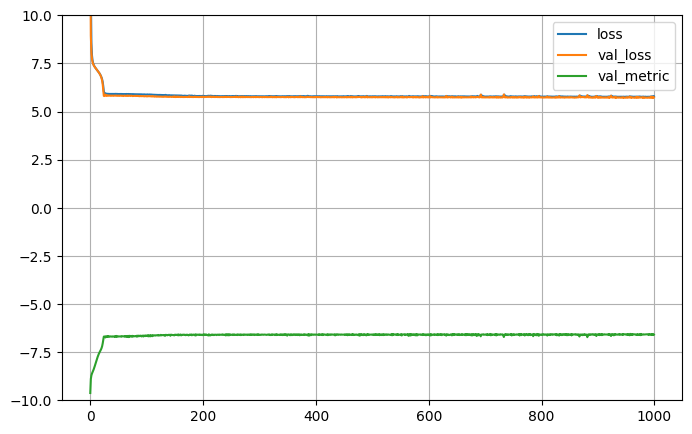

In [15]:
model = run_model(xtrain, ytrain, xvalid, yvalid, epoch=1000)



In [16]:
# Build test matrix with the same numeric coercion to prevent object dtype.
Xtestdf = sub[FEATURES].apply(pd.to_numeric, errors="coerce")
if Xtestdf.isna().any().any():
    Xtestdf = Xtestdf.fillna(Xtestdf.median(numeric_only=True))

xtest = Xtestdf.to_numpy(dtype=np.float32)

yans = model.predict(xtest, verbose=0)

out = pd.DataFrame(
    {
        "Patient_Week": sub["Patient_Week"].values,
        "FVC": yans[:, 0].astype(float),
        "Confidence": np.abs(yans[:, 1]).astype(float),
    }
)

out["Confidence"] = out["Confidence"].clip(lower=70.0)

# Ensure exact submission ordering matches sample_submission.csv
out = out.merge(
    pd.read_csv(f"{DATA_DIR}/sample_submission.csv")[["Patient_Week"]],
    on="Patient_Week",
    how="right",
)

# Fill any missing predictions defensively (shouldn't happen)
out["FVC"] = out["FVC"].fillna(out["FVC"].median())
out["Confidence"] = out["Confidence"].fillna(70.0)



In [17]:
out



,Patient_Week,FVC,Confidence
0,ID00126637202218610655908_-3,2446.103027,70.000000
1,ID00126637202218610655908_-2,2443.457275,70.000000
2,ID00126637202218610655908_-1,2440.782471,70.000000
3,ID00126637202218610655908_0,2438.528320,70.000000
4,ID00126637202218610655908_1,2435.967041,70.000000
...,...,...,...
1903,ID00047637202184938901501_98,3071.429932,399.389069
1904,ID00047637202184938901501_99,3070.325928,401.064148
1905,ID00047637202184938901501_100,3069.720459,402.850006
1906,ID00047637202184938901501_101,3069.092285,404.796265


In [18]:
out.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", out.shape)
print(out.head())

Wrote submission.csv with shape: (1908, 3)
                   Patient_Week          FVC  Confidence
0  ID00126637202218610655908_-3  2446.103027        70.0
1  ID00126637202218610655908_-2  2443.457275        70.0
2  ID00126637202218610655908_-1  2440.782471        70.0
3   ID00126637202218610655908_0  2438.528320        70.0
4   ID00126637202218610655908_1  2435.967041        70.0
